# Evaluation - In-distribution comparison

Head-to-head of every trained pipeline on the `ai-real-images` test set: a master metrics table, ranked bars, ROC/PR overlays, reliability, and a confusion-matrix grid.

**Sections:** 0 Setup - 1 Master table - 2 Ranked bars - 3 ROC/PR overlay - 4 Reliability - 5 Confusion grid - 6 Summary

> Reads each pipeline's committed artifacts and reconstructs trained models via `utils.eval_protocols` (rebuilt from `best_params.json`). Run after training completes.

## 0 - Setup

In [1]:
import sys, json, math
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

_here = Path.cwd()
_nb = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb) not in sys.path:
    sys.path.insert(0, str(_nb))

from utils import eval_protocols as EP, metrics as Me, viz as V, datasets as D, explain as E, eda

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT = EP.ART / "evaluation" / "figures"
OUT.mkdir(parents=True, exist_ok=True)
TAB = EP.ART / "evaluation"
PIPES = EP.available()
print("device:", device)
print("pipelines with trained results:", PIPES)

device: cuda
pipelines with trained results: ['cnn-scratch', 'cnn-residual', 'cnn-finetune', 'vit-lora', 'clip-probe', 'two-stream', 'freqcross', 'srm-noise', 'patch-ensemble', 'dire-recon']


## 1 - Master metrics table (in-distribution, threshold 0.5 and tuned)

Read straight from each pipeline's `metrics.json` (no model loading needed).

In [2]:
KEYS = ["accuracy", "f1_macro", "auc_roc", "pr_auc", "precision", "recall", "mcc", "brier"]
rows = []
for n in PIPES:
    m = EP.metrics(n); a = m["in_distribution"]["at_0.5"]; t = m["in_distribution"]["at_tuned"]
    row = {"pipeline": n}
    row.update({k: a[k] for k in KEYS})
    row["acc_tuned"] = t["accuracy"]; row["f1_tuned"] = t["f1_macro"]
    rows.append(row)
tbl = pd.DataFrame(rows).sort_values("auc_roc", ascending=False).reset_index(drop=True)
display(tbl.round(4))
tbl.round(6).to_csv(TAB / "in_distribution_comparison.csv", index=False)
print("saved", TAB / "in_distribution_comparison.csv")

,pipeline,accuracy,f1_macro,auc_roc,pr_auc,precision,recall,mcc,brier,acc_tuned,f1_tuned
0,vit-lora,0.9782,0.9782,0.9972,0.9969,0.9784,0.9779,0.9564,0.0172,0.9781,0.9781
1,patch-ensemble,0.9681,0.9681,0.9963,0.9960,0.9863,0.9493,0.9368,0.0229,0.9739,0.9739
2,cnn-finetune,0.9559,0.9559,0.9930,0.9936,0.9432,0.9702,0.9123,0.0357,0.9585,0.9585
3,clip-probe,0.9592,0.9592,0.9930,0.9932,0.9610,0.9572,0.9184,0.0318,0.9578,0.9578
4,freqcross,0.9003,0.9001,0.9651,0.9666,0.9310,0.8645,0.8026,0.0749,0.9048,0.9048
5,cnn-scratch,0.9011,0.9011,0.9648,0.9664,0.9140,0.8854,0.8026,0.0735,0.9014,0.9014
6,two-stream,0.8977,0.8977,0.9609,0.9604,0.9019,0.8923,0.7954,0.0862,0.8982,0.8982
7,srm-noise,0.8824,0.8824,0.9518,0.9486,0.8897,0.8728,0.7649,0.0855,0.8810,0.8809
8,dire-recon,0.8730,0.8730,0.9399,0.9308,0.8791,0.8650,0.7461,0.1058,0.8645,0.8641
9,cnn-residual,0.7868,0.7864,0.8672,0.8563,0.7625,0.8327,0.5762,0.1505,0.7883,0.7883


saved C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\artifacts\evaluation\in_distribution_comparison.csv


## 2 - Ranked bar charts

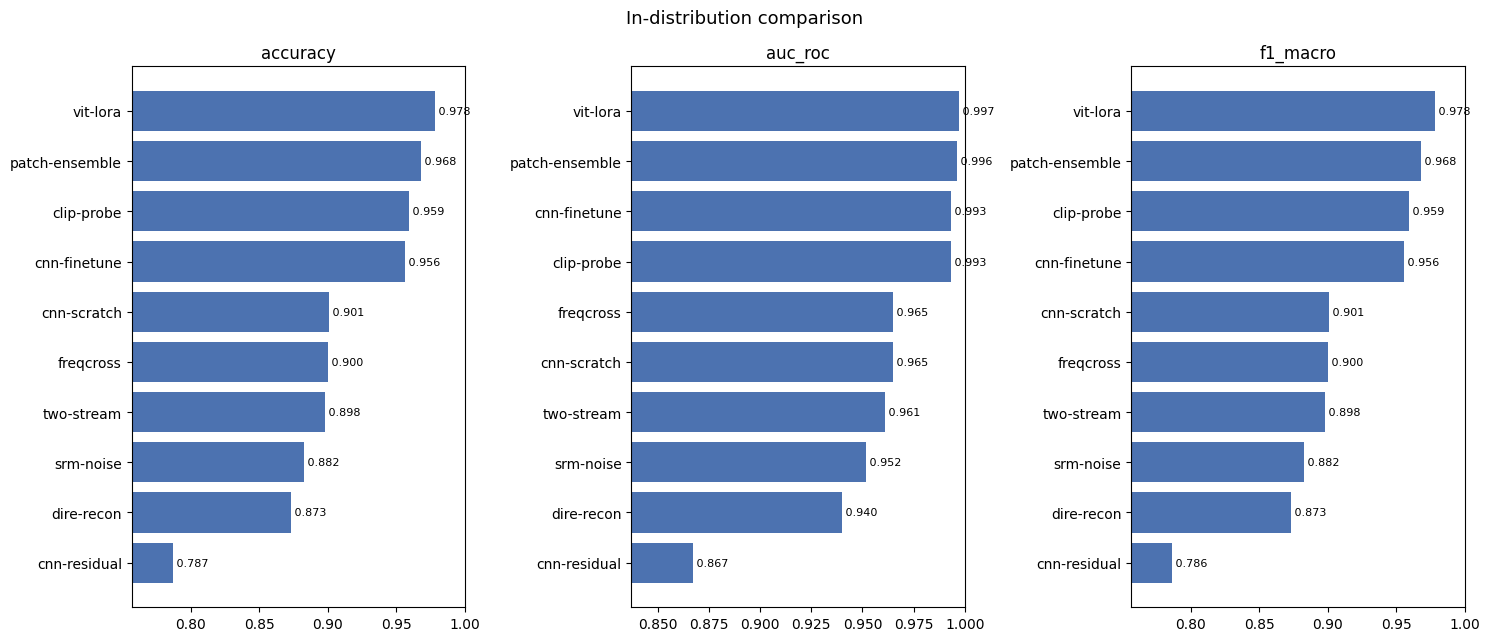

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 0.45 * len(tbl) + 2))
for ax, met in zip(axes, ["accuracy", "auc_roc", "f1_macro"]):
    t = tbl.sort_values(met)
    ax.barh(t["pipeline"], t[met], color="#4C72B0")
    ax.set_title(met); ax.set_xlim(max(0.4, float(t[met].min()) - 0.03), 1.0)
    for i, v in enumerate(t[met]):
        ax.text(v, i, f" {v:.3f}", va="center", fontsize=8)
fig.suptitle("In-distribution comparison", fontsize=13); fig.tight_layout()
fig.savefig(OUT / "indist_bars.png", dpi=150, bbox_inches="tight"); plt.show()

## 3 - ROC / PR overlays

Reconstructs each model and scores the test set. Set `RECOMPUTE=False` to skip (the table above already summarizes results).

C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\datasets.py:166: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  t = torch.from_numpy(arr).permute(2, 0, 1).contiguous()    # CHW uint8


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (143040000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (121554000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


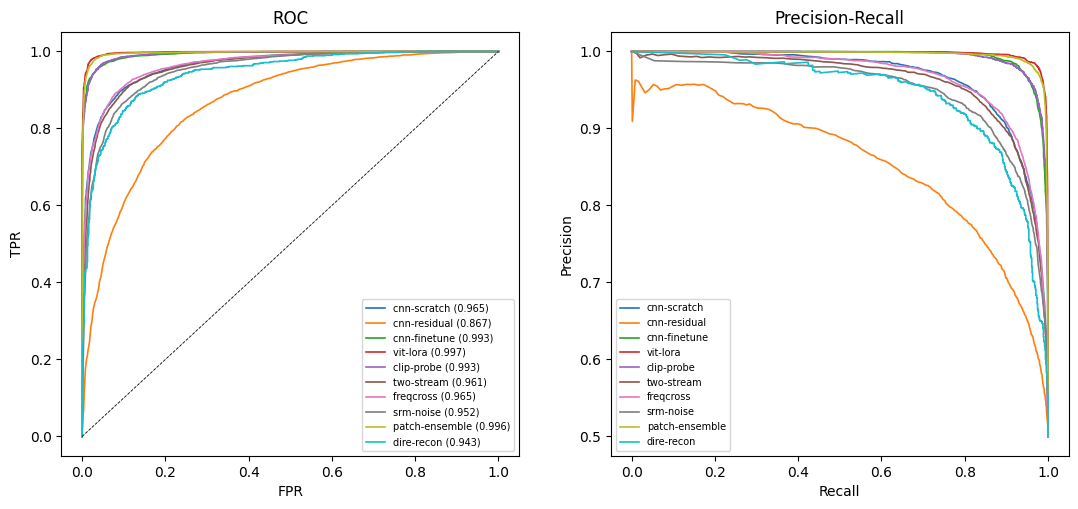

In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
RECOMPUTE = True
if RECOMPUTE:
    probs = {}
    for n in PIPES:
        model = EP.load_model(n, device)
        y, p = EP.indist_probs(n, model, device)
        probs[n] = (y, p)
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.5))
    for n, (y, p) in probs.items():
        fpr, tpr, _ = roc_curve(y, p); a1.plot(fpr, tpr, lw=1.2, label=f"{n} ({auc(fpr, tpr):.3f})")
        pr, rc, _ = precision_recall_curve(y, p); a2.plot(rc, pr, lw=1.2, label=n)
    a1.plot([0, 1], [0, 1], "k--", lw=0.6); a1.set_xlabel("FPR"); a1.set_ylabel("TPR"); a1.set_title("ROC"); a1.legend(fontsize=7)
    a2.set_xlabel("Recall"); a2.set_ylabel("Precision"); a2.set_title("Precision-Recall"); a2.legend(fontsize=7)
    fig.savefig(OUT / "roc_pr_overlay.png", dpi=150, bbox_inches="tight"); plt.show()
else:
    probs = None

## 4 - Reliability (calibration) overlay

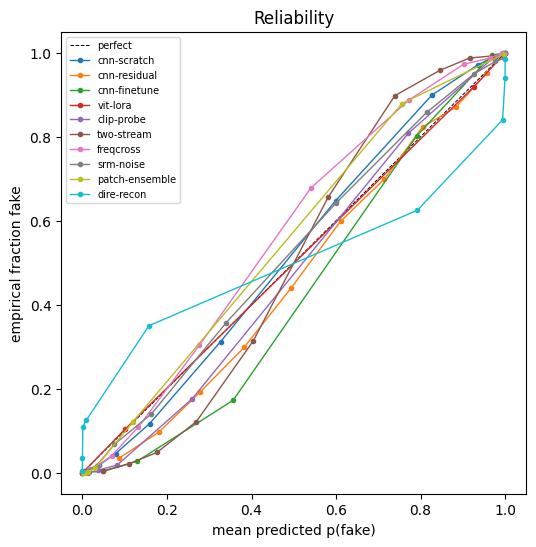

In [5]:
if probs:
    from sklearn.calibration import calibration_curve
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], "k--", lw=0.7, label="perfect")
    for n, (y, p) in probs.items():
        frac, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac, marker="o", ms=3, lw=1, label=n)
    ax.set_xlabel("mean predicted p(fake)"); ax.set_ylabel("empirical fraction fake")
    ax.set_title("Reliability"); ax.legend(fontsize=7)
    fig.savefig(OUT / "reliability_overlay.png", dpi=150, bbox_inches="tight"); plt.show()

## 5 - Confusion-matrix grid (threshold 0.5, from metrics.json)

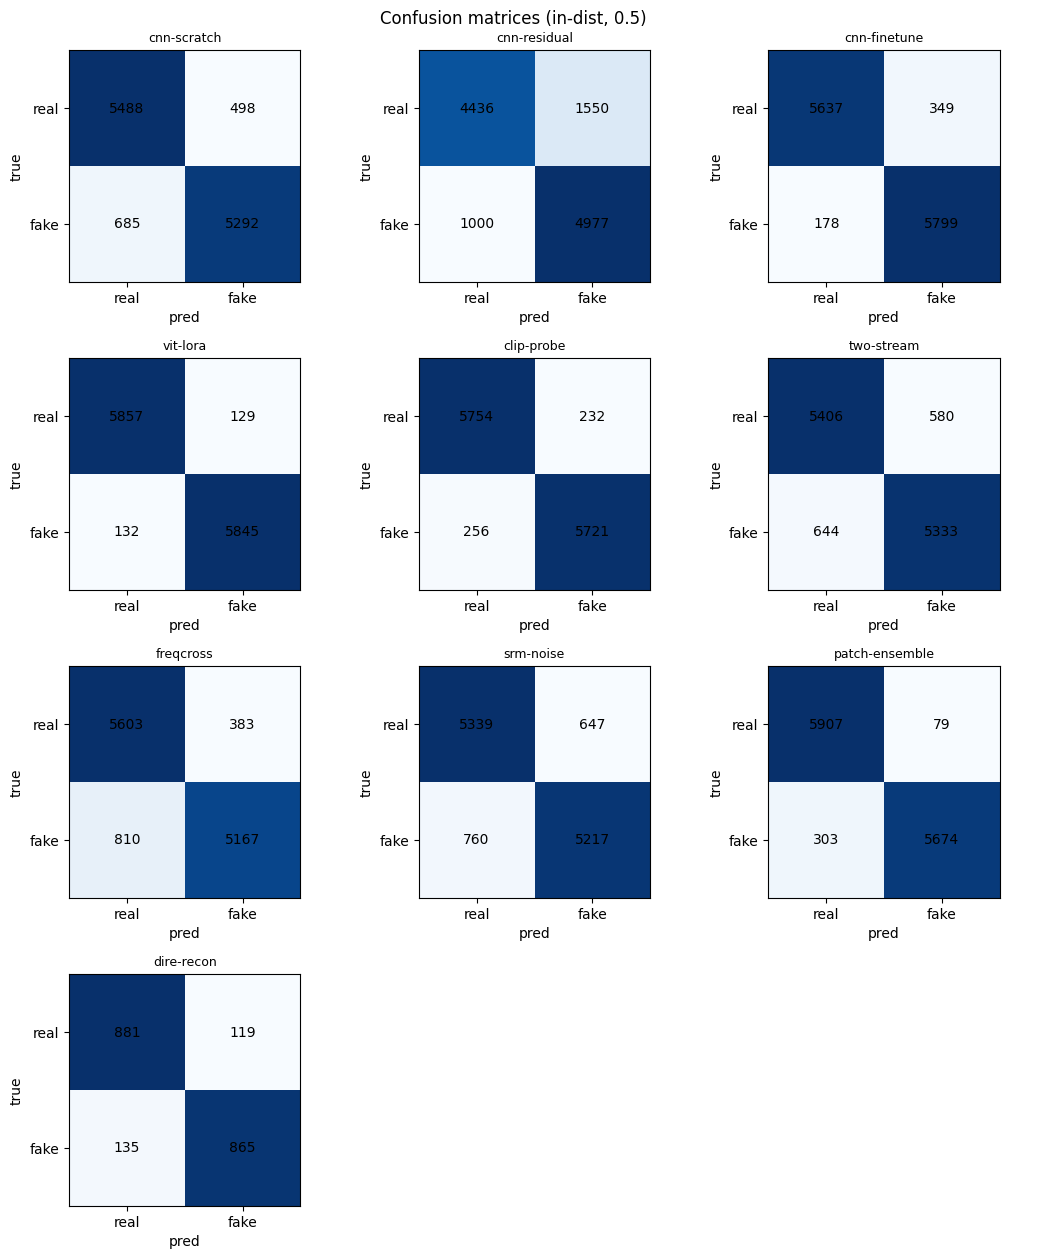

In [6]:
cols = 3; rows_ = math.ceil(len(PIPES) / cols)
fig, axes = plt.subplots(rows_, cols, figsize=(3.6 * cols, 3.2 * rows_)); axes = np.array(axes).reshape(-1)
for ax, n in zip(axes, PIPES):
    cm = np.array(EP.metrics(n)["in_distribution"]["at_0.5"]["confusion_matrix"])
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, int(v), ha="center", va="center")
    ax.set_title(n, fontsize=9); ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["real", "fake"]); ax.set_yticklabels(["real", "fake"]); ax.set_xlabel("pred"); ax.set_ylabel("true")
for ax in axes[len(PIPES):]:
    ax.axis("off")
fig.suptitle("Confusion matrices (in-dist, 0.5)"); fig.tight_layout()
fig.savefig(OUT / "confusion_grid.png", dpi=150, bbox_inches="tight"); plt.show()

## 6 - Summary

In [7]:
best = tbl.iloc[0]
print(f"Best in-distribution AUC: {best['pipeline']}  (AUC {best['auc_roc']:.4f}, acc {best['accuracy']:.4f}, F1 {best['f1_macro']:.4f})")
print("\nFull ranking by AUC:")
display(tbl[["pipeline", "accuracy", "auc_roc", "f1_macro", "mcc", "brier"]].round(4))

Best in-distribution AUC: vit-lora  (AUC 0.9972, acc 0.9782, F1 0.9782)

Full ranking by AUC:


,pipeline,accuracy,auc_roc,f1_macro,mcc,brier
0,vit-lora,0.9782,0.9972,0.9782,0.9564,0.0172
1,patch-ensemble,0.9681,0.9963,0.9681,0.9368,0.0229
2,cnn-finetune,0.9559,0.9930,0.9559,0.9123,0.0357
3,clip-probe,0.9592,0.9930,0.9592,0.9184,0.0318
4,freqcross,0.9003,0.9651,0.9001,0.8026,0.0749
5,cnn-scratch,0.9011,0.9648,0.9011,0.8026,0.0735
6,two-stream,0.8977,0.9609,0.8977,0.7954,0.0862
7,srm-noise,0.8824,0.9518,0.8824,0.7649,0.0855
8,dire-recon,0.8730,0.9399,0.8730,0.7461,0.1058
9,cnn-residual,0.7868,0.8672,0.7864,0.5762,0.1505
